In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ee
from IPython.display import Image as IPImage, display
import time
import urllib.request
from PIL import Image
import io

In [2]:
data = pd.read_csv(r"C:\Users\odin0\Downloads\knmi_grondwater.csv")
data["tg"] = data["tg"]/10
data["rh"] = data["rh"]*10
data["ev24"] = data["ev24"]*10
data["datum"] = pd.to_datetime(data["datum"])

date_from = "28-03-2021"
date_to   = "28-01-2022"
meetpunt = "131565-9"

data_filtered = data[
    (data['datum'] > date_from) &
    (data['datum'] < date_to) &
    (data['meetpunt'] == meetpunt)
]


C:\Users\odin0\AppData\Local\Temp\ipykernel_5876\817218840.py:1: DtypeWarning: Columns (20,21,22,23,24,25,28,34) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\odin0\Downloads\knmi_grondwater.csv")


In [3]:
try:
    ee.Initialize(project='kmeans-test-461921')
except:
    ee.Authenticate()
    ee.Initialize(project='kmeans-test-461921')

In [4]:
gadm = ee.FeatureCollection("FAO/GAUL/2015/level2")
rotterdam_polygon = ee.Geometry.Polygon([
  [
    [4.37393, 51.84761],
    [4.51861, 51.84761],
    [4.57217, 51.87876],
    [4.59054, 51.92672],
    [4.54891, 51.95635],
    [4.47011, 51.98732],
    [4.40512, 51.98614],
    [4.35388, 51.95569],
    [4.35393, 51.84761]
  ]
])

In [5]:
def maskS2(img):
    # SCL masker: hou alleen goede landpixels
    scl = img.select("SCL")
    good = (
        scl.eq(4)   # vegetation
        .Or(scl.eq(5))  # bare soil
        .Or(scl.eq(6))  # water
        .Or(scl.eq(7))  # unclassified
        .Or(scl.eq(10)) # clouds (rarely actually ok)
    )
    return img.updateMask(good)

def addNDVI(img):
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img.addBands(ndvi)

In [6]:
start_month = (pd.to_datetime(date_from, dayfirst=True) + pd.offsets.MonthBegin(1)).normalize()
end_month   = (pd.to_datetime(date_to, dayfirst=True) - pd.offsets.MonthBegin(1)).normalize()
months = pd.date_range(start_month, end_month, freq='MS')

ndvi_list = []
month_labels = []
start_image = None
end_image   = None

In [7]:
for i, m in enumerate(months):
    month_end = m + pd.offsets.MonthEnd(0)

    col = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(m.strftime("%Y-%m-%d"), month_end.strftime("%Y-%m-%d"))
        .filterBounds(rotterdam_polygon)
        .map(addNDVI)    # <-- EERST NDVI MAKEN
        .map(maskS2)     # <-- DAN PAS MASKEREN
    )
    
    median = col.median()
    
    bands = median.bandNames().getInfo()
    if "NDVI" not in bands:
        ndvi_list.append(np.nan)
        month_labels.append(m.to_period('M'))
        continue
    
    # Start/eind afbeelding opslaan
    if i == 0:
        start_image = median
    if i == len(months)-1:
        end_image = median

    mean_dict = median.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=rotterdam_polygon,
        scale=20,
        maxPixels=1e9,
        bestEffort=True
    )
    
    v = mean_dict.get("NDVI")
    ndvi_list.append(v.getInfo() if v is not None else np.nan)
    month_labels.append(m.to_period("M"))


In [8]:
data_filtered = data_filtered.copy()
data_filtered["maand"] = data_filtered["datum"].dt.to_period("M")
data_filtered["ndvi"] = data_filtered["maand"].map(pd.Series(ndvi_list, index=month_labels))

In [9]:
region_json = rotterdam_polygon.getInfo()

start_ndvi = start_image.select("NDVI")
end_ndvi   = end_image.select("NDVI")

url1 = start_ndvi.getThumbURL({
    "min": 0, "max": 0.8,
    "palette": ['#d7191c','#fdae61','#ffffbf','#a6d96a','#1a9641'],
    "dimensions": 1024,
    "region": region_json
})

url2 = end_ndvi.getThumbURL({
    "min": 0, "max": 0.8,
    "palette": ['#d7191c','#fdae61','#ffffbf','#a6d96a','#1a9641'],
    "dimensions": 1024,
    "region": region_json
})


In [10]:
img1 = np.array(Image.open(io.BytesIO(urllib.request.urlopen(url1).read())))
img2 = np.array(Image.open(io.BytesIO(urllib.request.urlopen(url2).read())))

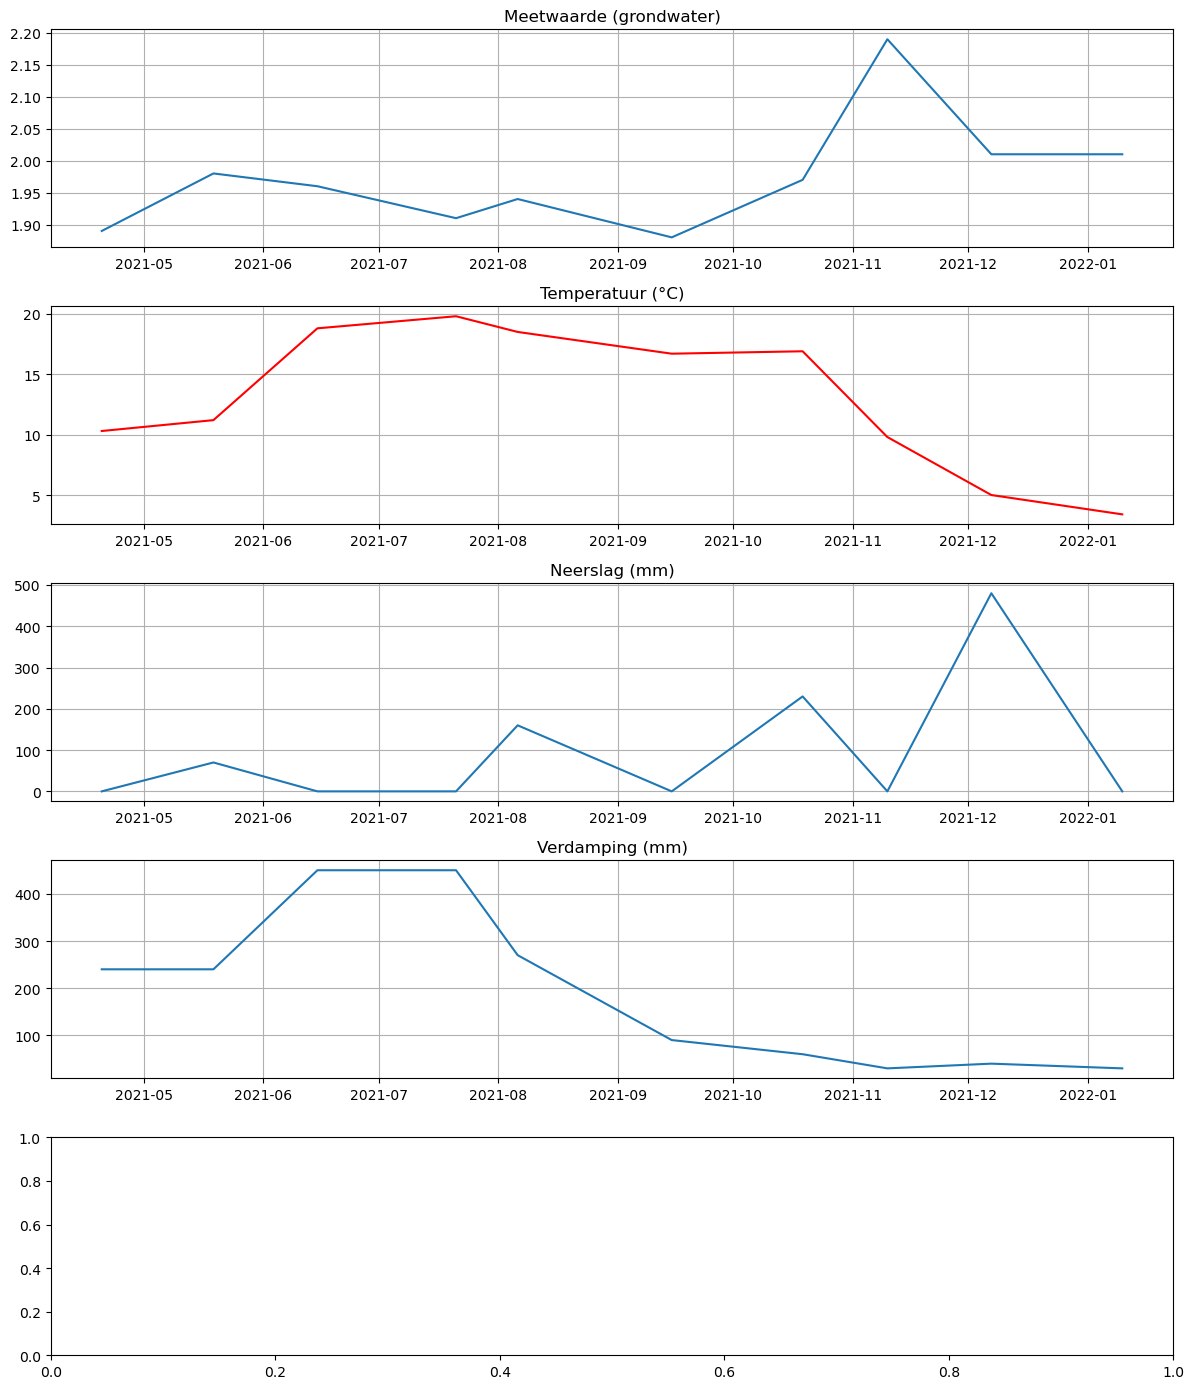

In [11]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14))

axes[0].plot(data_filtered["datum"], data_filtered["meetwaarde"])
axes[0].set_title("Meetwaarde (grondwater)")
axes[0].grid(True)

axes[1].plot(data_filtered["datum"], data_filtered["tg"], color='red')
axes[1].set_title("Temperatuur (°C)")
axes[1].grid(True)

axes[2].plot(data_filtered["datum"], data_filtered["rh"], color='tab:blue')
axes[2].set_title("Neerslag (mm)")
axes[2].grid(True)

axes[3].plot(data_filtered["datum"], data_filtered["ev24"])
axes[3].set_title("Verdamping (mm)")
axes[3].grid(True)

# axes[4].plot(data_filtered["datum"], data_filtered["ndvi"], color='green', linewidth=2.5)
# axes[4].set_title("Gemiddelde NDVI – Rotterdam")
# axes[4].set_ylim(0, 0.9)
# axes[4].grid(True)

plt.tight_layout()
plt.show()

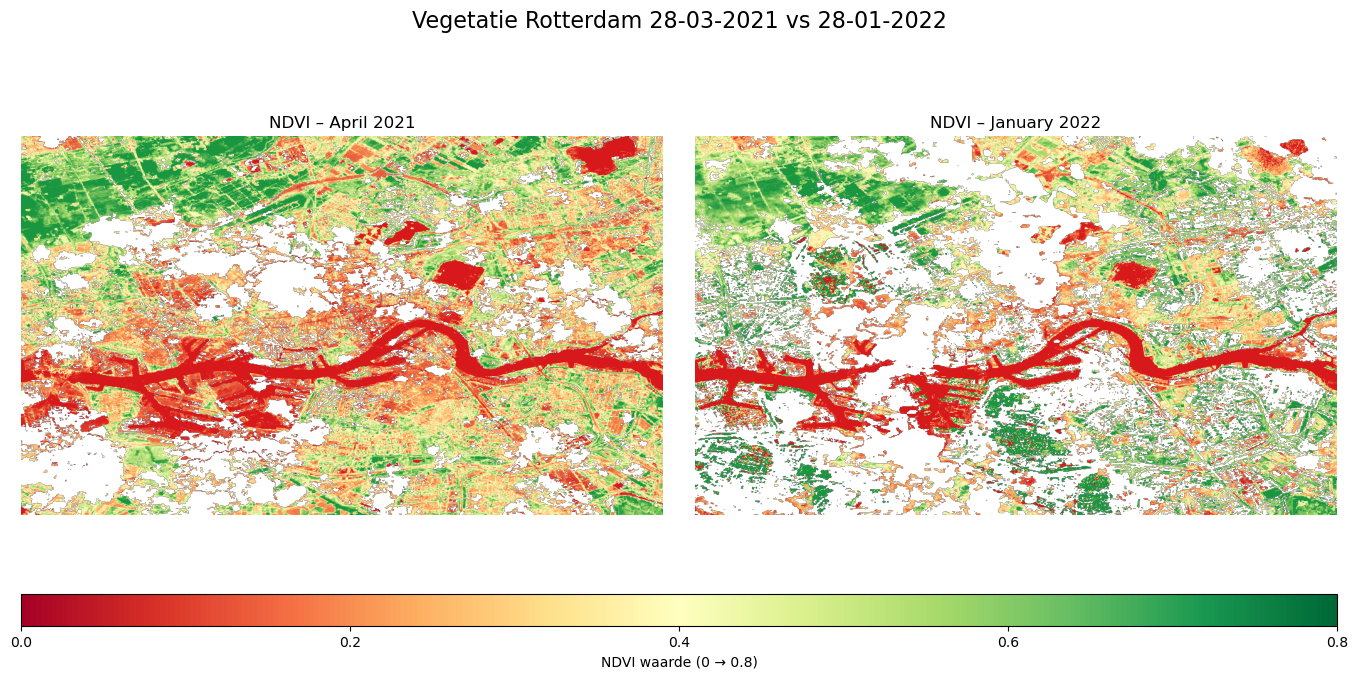

In [12]:
import matplotlib.pyplot as plt
import matplotlib

# Compactere layout
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[8, 8, 1],   # compacter dan 10-10-1
    hspace=0.05,               # bijna geen verticale ruimte tussen rijen
    wspace=0.05                # bijna geen horizontale ruimte tussen kolommen
)

ax1 = fig.add_subplot(gs[0:2, 0])
ax2 = fig.add_subplot(gs[0:2, 1])
cax = fig.add_subplot(gs[2, :])

# --- PLOT NDVI KAARTEN ---
ax1.imshow(img1)
ax1.set_title(f"NDVI – {start_month.strftime('%B %Y')}")
ax1.axis("off")

ax2.imshow(img2)
ax2.set_title(f"NDVI – {end_month.strftime('%B %Y')}")
ax2.axis("off")

# --- COLORBAR ---
sm = matplotlib.cm.ScalarMappable(
    cmap=matplotlib.colormaps["RdYlGn"],
    norm=matplotlib.colors.Normalize(vmin=0, vmax=0.8)
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label("NDVI waarde (0 → 0.8)")
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8])

# --- TITEL ---
fig.suptitle(
    "Vegetatie Rotterdam " + date_from + " vs " + date_to,
    fontsize=16,
    y=0.98
)

# --- MARGES VERKLEINEN (ERG BELANGRIJK!) ---
plt.subplots_adjust(
    top=0.90,
    bottom=0.10,
    left=0.03,
    right=0.97
)

plt.show()
